In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

run = pickle.loads(Path(".run.pkl").read_bytes())
card, ev, constants = run["card"], run["evidence"], run["constants"]
gates = {g["number"]: g for g in run["gates"]}
pd.set_option("display.max_colwidth", None)
plt.rcParams.update({"figure.figsize": (9, 3), "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "axes.titlesize": 10})
INK, GREY, MARK = "#1f4e79", "#a6a6a6", "#c0504d"


def text(value):
    return " ".join(str(value).split()) if value else "—"


def shown(value):
    if value is None:
        return "—"
    if isinstance(value, (list, tuple)):
        return "; ".join(map(str, value)) or "none"
    if isinstance(value, float):
        return float(f"{value:.4g}")
    return value


def table(figures):
    display(pd.Series({k: shown(v) for k, v in figures.items()}, dtype=object).to_frame().T.set_index(pd.Index([""])))


def gate(number):
    g = gates[number]
    reason = g["reason"].removeprefix("not computed: ")
    word = {True: "Passes", False: "Fails", None: "Not computed"}[g["passed"]]
    display(Markdown(f"**{word}**: {reason.rstrip('.')}."))
    if g["figures"]:
        table(g["figures"])


failed = run["failed"]
headline = ("passes gates 1 to 7" if failed is None
            else f"stops at gate {failed}, {gates[failed]['name'].lower()}: {gates[failed]['reason']}")
display(Markdown(f"# {card['id']}\n\nTheory **{card.get('theory', '—')}**. The battery's verdict: "
                 f"the strategy {headline}."))

# TM-047-01-volatility-scaled-trend

Theory **TM-047**. The battery's verdict: the strategy stops at gate 3, significance: beats 83.9% of its shifted placebos, fewer than 90%.

## Thesis

In [2]:
prediction = card.get("prediction") or {}
if isinstance(prediction, dict):
    prediction = ", ".join(f"{k}: {v}" for k, v in prediction.items())
display(Markdown(f"**Mechanism.** {text(card.get('mechanism'))}\n\n"
                 f"**Prediction.** {text(prediction)}\n\n"
                 f"**What would refute it.** {text(card.get('refuted_if'))}\n\n"
                 f"**Horizon.** {text(card.get('horizon'))}"))

**Mechanism.** Momentum is rewarded better when volatility is low than when it is high, and suffers its worst drawdowns when volatility is high. Sizing each position by the inverse of its asset's recent volatility makes every position carry about the same risk and takes less risk when volatility rises: an implicit timing of the exposure that raises the Sharpe ratio of the same momentum rule.

**Prediction.** sign: positive, size: a Sharpe ratio of about 0.58 in-sample, above the 0.495 of the same rule in equal shares (TM-017-01), and a positive alpha over the seven assets held always

**What would refute it.** The theory is refuted in this form if the scaled rule's Sharpe ratio falls short of the 0.495 of the same rule in equal shares over the same years by more than 0.1, about one standard error of the difference between two rules this close; or if it earns an alpha of zero or less over the seven assets held always; or if it beats about half of its placebos shifted in time or fewer. A Sharpe ratio within 0.1 of 0.495, or a positive alpha that beats more than half of its placebos but fewer than the battery's 90%, or a result that rests on one cluster, one asset or one episode, is not proven, not refuted.

**Horizon.** months

## Data

In [3]:
x = ev.get("excess")
start, end = constants["in sample"]
cannot_run = gates[1]["reason"].startswith("the strategy cannot run")
broke = gates[1]["reason"].startswith("cannot be computed: ")        # the runs every gate judges broke
evaluated = (f"evaluated from the first session the strategy holds an asset, {x.index[0].date()}, to "
             f"{x.index[-1].date()}" if x is not None and len(x)
             else "not evaluated: the strategy cannot run" if cannot_run
             else f"not evaluated: the runs every gate judges broke ({gates[1]['reason'].split(': ', 1)[1]})"
             if broke else "not evaluated: nothing was held")
display(Markdown(
    f"Daily closes adjusted for dividends and splits, snapshot **{run['snapshot']}**. "
    f"Universe: {', '.join(card['universe'])}. In-sample {start} to {end}, {evaluated}; "
    f"holdout {' to '.join(constants['holdout'])}, opened once, at gate 7. "
    f"Returns are above the Treasury-bill rate, net of costs."))

Daily closes adjusted for dividends and splits, snapshot **2026-09-22+2026-09-23**. Universe: SPY, EFA, EEM, IEF, TLT, GLD, DBC. In-sample 2005-01-01 to 2022-12-31, evaluated from the first session the strategy holds an asset, 2006-02-01, to 2022-12-30; holdout 2023-01-01 to 2025-12-31, opened once, at gate 7. Returns are above the Treasury-bill rate, net of costs.

## Signal

On the first session of each month, an asset is in trend when its return over the past 252 sessions, read up to the session before, beats the Treasury bill's over the same sessions. Each asset in trend is held at a weight of risk divided by its daily volatility, the standard deviation of its daily returns over the past vol_window sessions, read up to the session before; when these weights add up to more than one, all are cut in the same proportion until they add up to one. An asset out of trend, or without 252 sessions of prices and vol_window returns, is not held; what the weights leave is cash.

- **risk**: the daily move, as a fraction of the portfolio, that each position's typical daily move is set to
- **vol_window**: sessions of daily returns whose standard deviation measures an asset's volatility

,risk,vol_window
base,0.00125,100
variant 1,0.00125,21


Parameter neighbours, moved one at a time for gate 6: risk at ±25%: 0.00094, 0.00156; risk at ±50%: 0.000625, 0.001875; vol_window at ±25%: 75, 125; vol_window at ±50%: 50, 150.

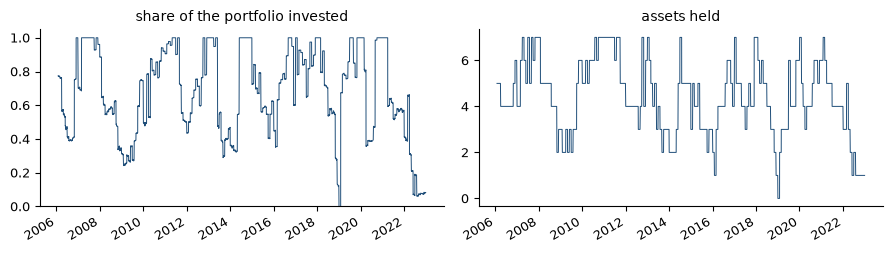

In [4]:
display(Markdown(text(card.get("signal"))))
parameters = card.get("parameters") or {}
if parameters:
    display(Markdown("\n".join(f"- **{k}**: {text(v)}" for k, v in parameters.items())))
variants = pd.DataFrame(card["variants"], index=["base"] + [f"variant {k}" for k in range(1, len(card["variants"]))])
display(variants)
neighbours = card.get("neighbours") or {}
if neighbours:
    display(Markdown("Parameter neighbours, moved one at a time for gate 6: "
                     + "; ".join(f"{p} at ±{step}%: {', '.join(map(str, values))}"
                                 for p, steps in neighbours.items() for step, values in steps.items()) + "."))
if "exposure" in ev:
    fig, (a, b) = plt.subplots(1, 2, figsize=(9, 2.6))
    ev["exposure"].plot(ax=a, color=INK, linewidth=0.7)
    a.set_title("share of the portfolio invested")
    a.set_ylim(0, 1.05)
    ev["assets held"].plot(ax=b, color=INK, linewidth=0.7)
    b.set_title("assets held")
    for axis in (a, b):
        axis.set_xlabel("")
    plt.tight_layout()

## Equity against the benchmark

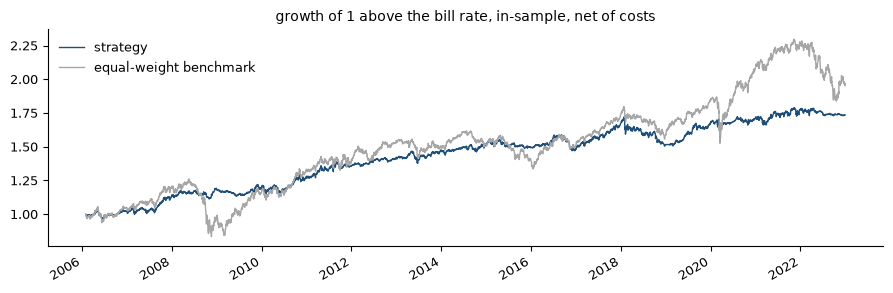

In [5]:
if x is not None and len(x):
    b = ev["benchmark excess"]
    fig, ax = plt.subplots()
    (1 + x).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + b).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title("growth of 1 above the bill rate, in-sample, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
else:
    display(Markdown("The strategy cannot run: there is no equity to draw." if cannot_run
                     else "The runs every gate judges broke: there is no equity to draw." if broke
                     else "Nothing was held in-sample: there is no equity to draw."))

## Gate 1 · Hygiene

Protects against look-ahead, bad data and too little evidence.

**Passes**: no look-ahead on 200 dates, 203 decisions over 16.9 years.

,dates checked,look-ahead breaks,same-day breaks,data problems,clustered decisions,years in-sample,years needed
,200,0,0,none,203,16.9,5


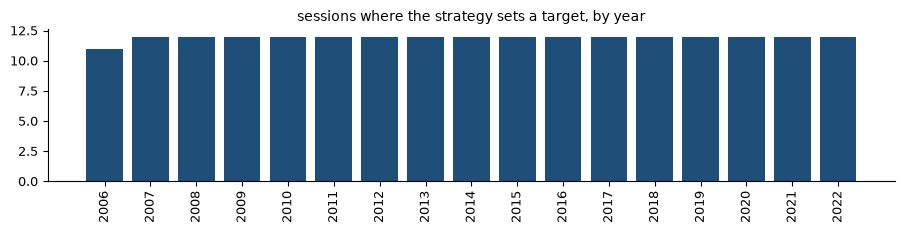

In [6]:
gate(1)
days = ev.get("target days")
if days is not None and len(days):
    per_year = pd.Series(1, index=days).groupby(days.year).sum()
    fig, ax = plt.subplots(figsize=(9, 2.4))
    ax.bar(per_year.index.astype(str), per_year, color=INK)
    breaks = sorted({d.year for variant in ev["timing breaks"].values() for kind in variant.values() for d in kind})
    for year in breaks:
        ax.bar(str(year), per_year.get(year, 0), color=MARK)
    ax.set_title("sessions where the strategy sets a target, by year" + ("; red: a timing break" if breaks else ""))
    ax.tick_params(axis="x", rotation=90)
    plt.tight_layout()

## Gate 2 · Economic edge

Protects against an edge explained by costs or by market exposure.

**Passes**: Sharpe 0.58 against the benchmark's 0.41, alpha 2.03%, 0.56 at twice the costs.

,Sharpe,benchmark Sharpe,alpha,Sharpe at 2x costs,alpha at 2x costs,gross Sharpe,costs a year,costs in Sharpe units
,0.581,0.407,0.0203,0.5627,0.01928,0.5993,0.001091,0.01844


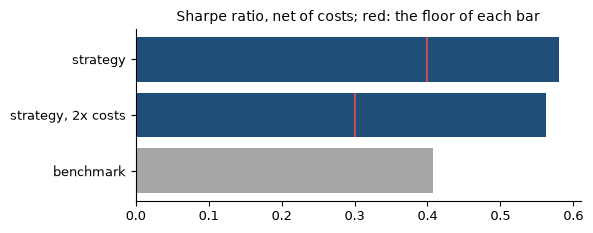

In [7]:
gate(2)
f = gates[2]["figures"]
if f:
    floors = constants["floors"]
    rows = [("benchmark", f["benchmark Sharpe"], GREY, None),
            ("strategy, 2x costs", f["Sharpe at 2x costs"], INK, floors["Sharpe at 2x costs"]),
            ("strategy", f["Sharpe"], INK, floors["Sharpe"])]
    fig, ax = plt.subplots(figsize=(6, 2.4))
    for y, (label, value, colour, floor) in enumerate(rows):
        ax.barh(y, value, color=colour)
        if floor is not None:
            ax.vlines(floor, y - 0.4, y + 0.4, color=MARK, linewidth=1.5)
    ax.set_yticks(range(len(rows)), [r[0] for r in rows])
    ax.set_title("Sharpe ratio, net of costs; red: the floor of each bar")
    plt.tight_layout()

## Gate 3 · Significance

Protects against luck, and against being paid only for being invested. A strategy that holds nearly every asset that trades is close to its benchmark: its placebos differ from it by little, details of the path decide its rank, and gates 2 and 4 judge it.

**Fails**: beats 83.9% of its shifted placebos, fewer than 90%.

,PSR,placebo sessions,placebos,placebos beaten
,0.9977,4259,1000,0.839


Assets that start trading after 2006-02-01: DBC. A placebo shifts their weights only between days when they trade. Where it draws from a day before their start, it keeps their own weights; where it draws from a day after their start onto a day before it, the share it cannot hold yet takes the strategy's own weights of that day, and with them its timing: skill that lies before a late start is judged against placebos that share it, and is found less often. Where the strategy holds none of the assets shifted that day, the shifted weights take that share instead.

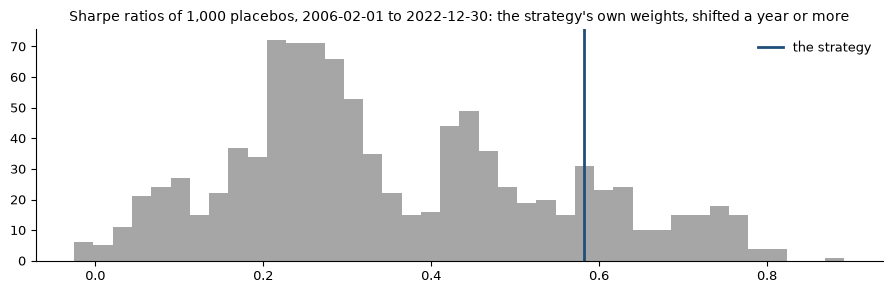

In [8]:
gate(3)
if "placebos" in ev:
    fig, ax = plt.subplots()
    ax.hist(ev["placebos"], bins=40, color=GREY)
    ax.axvline(ev["placebo own Sharpe"], color=INK, linewidth=2, label="the strategy")
    first, last = (d.date() for d in ev["placebo window"])
    ax.set_title(f"Sharpe ratios of {len(ev['placebos']):,} placebos, {first} to {last}: the strategy's own weights, "
                 f"shifted a year or more")
    ax.legend(frameon=False)
    plt.tight_layout()
    if ev.get("placebo late assets"):
        display(Markdown(f"Assets that start trading after {first}: {', '.join(ev['placebo late assets'])}. A placebo "
                         f"shifts their weights only between days when they trade. Where it draws from a day before their "
                         f"start, it keeps their own weights; where it draws from a day after their start onto a day before "
                         f"it, the share it cannot hold yet takes the strategy's own weights of that day, and with them its "
                         f"timing: skill that lies before a late start is judged against placebos that share it, and is "
                         f"found less often. Where the strategy holds none of the assets shifted that day, the shifted "
                         f"weights take that share instead."))

## Gate 4 · Multiple testing

Protects against the best of many tries: the edge, hedged of the benchmark, deflated by every trial the registry holds.

**Fails**: DSR 0.840 below 0.9 over 5 effective trials.

,trials,effective trials,appraisal ratio,Sharpe expected by luck,DSR
,6,5,0.4229,0.2901,0.8404


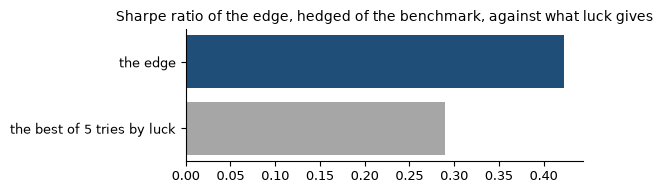

In [9]:
gate(4)
f = gates[4]["figures"]
if f and "appraisal ratio" in f:
    fig, ax = plt.subplots(figsize=(6, 2.0))
    ax.barh([0, 1], [f["Sharpe expected by luck"], f["appraisal ratio"]], color=[GREY, INK])
    tries = f["effective trials"]
    ax.set_yticks([0, 1], [f"the best of {tries} {'try' if tries == 1 else 'tries'} by luck", "the edge"])
    ax.set_title("Sharpe ratio of the edge, hedged of the benchmark, against what luck gives")
    plt.tight_layout()

## Gate 5 · Stability

Protects against an edge that lives in one variant or one episode.

**Fails**: the blend of the variants fails gates 3 and 4.

,blend passes gate 2,blend passes gate 3,blend passes gate 4,worst variant Sharpe,positive blocks,best year,alpha without the best year
,True,False,False,0.5577,5,2008,0.009678


The blend of the variants: gate 3, beats 87.3% of its shifted placebos, fewer than 90%; gate 4, DSR 0.820 below 0.9 over 5 effective trials.

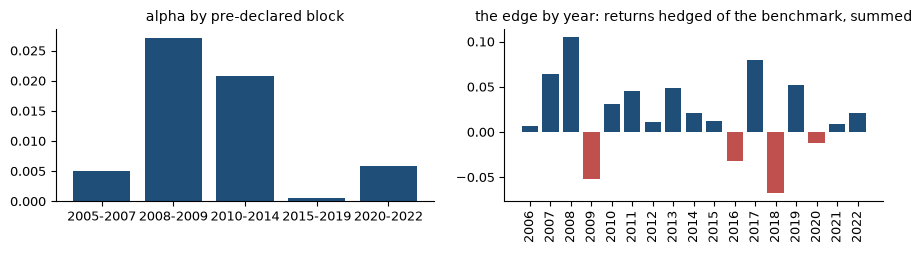

In [10]:
gate(5)
if "blocks" in ev:
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    blocks = pd.Series({k: (v if v is not None else np.nan) for k, v in ev["blocks"].items()})
    a.bar(blocks.index, blocks.fillna(0), color=[INK if v > 0 else MARK for v in blocks.fillna(0)])
    a.set_title("alpha by pre-declared block")
    a.axhline(0, color="black", linewidth=0.6)
    by_year = ev["edge by year"]
    c.bar(by_year.index.astype(str), by_year, color=[INK if v > 0 else MARK for v in by_year])
    c.set_title("the edge by year: returns hedged of the benchmark, summed")
    c.tick_params(axis="x", rotation=90)
    plt.tight_layout()
failed_blend = {n: reason for n, reason in ev.get("blend", {}).items() if gates[5]["figures"].get(f"blend passes gate {n}") is False}
if failed_blend:
    display(Markdown("The blend of the variants: " + "; ".join(f"gate {n}, {r}" for n, r in failed_blend.items()) + "."))

## Gate 6 · Robustness

Protects against a peak, one asset, timing too tight and a clone.

**Passes**: neighbours, clusters, assets, bitcoin, delay and survivors all hold.

,neighbour median ratio,lowest ±25% ratio,neighbours that hold the base,worst cluster out,worst cluster out ratio,largest P&L share,asset with the largest share,one day late ratio,highest correlation with a survivor,survivor most correlated
,1.001,0.9619,none,bonds,0.678,0.2816,SPY,1.002,—,—


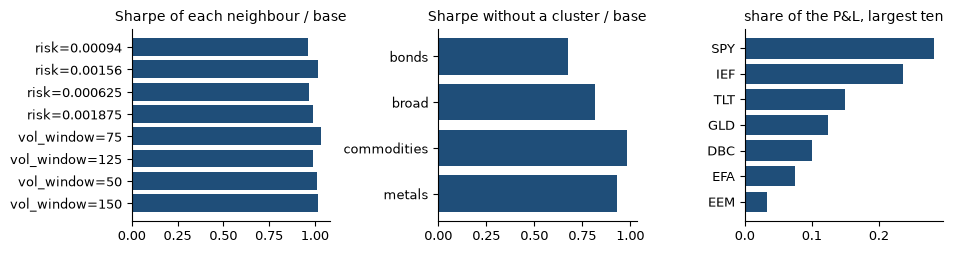

In [11]:
gate(6)
panels = [(k, ev.get(k)) for k in ("neighbours", "clusters out", "P&L shares") if ev.get(k) is not None and len(ev.get(k))]
if panels:
    fig, axes = plt.subplots(1, len(panels), figsize=(3.2 * len(panels), 2.6))
    for axis, (name, values) in zip(np.atleast_1d(axes), panels):
        values = pd.Series(values).head(10)
        axis.barh(values.index.astype(str), values, color=INK)
        axis.set_title({"neighbours": "Sharpe of each neighbour / base", "clusters out": "Sharpe without a cluster / base",
                        "P&L shares": "share of the P&L, largest ten"}[name])
        axis.invert_yaxis()
    plt.tight_layout()
if ev.get("without bitcoin"):
    display(Markdown("Without bitcoin, gate 2's figures:"))
    table(ev["without bitcoin"])

## Gate 7 · Sealed holdout

Protects against bugs and large decay, on years kept aside and opened once.

**Passes**: holdout Sharpe 0.73 and alpha -0.41%, both above the in-sample 10th percentile.

,holdout Sharpe,Sharpe floor,holdout alpha,alpha floor,variants rewritten,dates checked,look-ahead breaks,same-day breaks,data problems
,0.7257,-0.09164,-0.004109,-0.01555,0,40,0,0,none


Red: the 10th percentile of the in-sample paths, the floor; blue: the holdout.

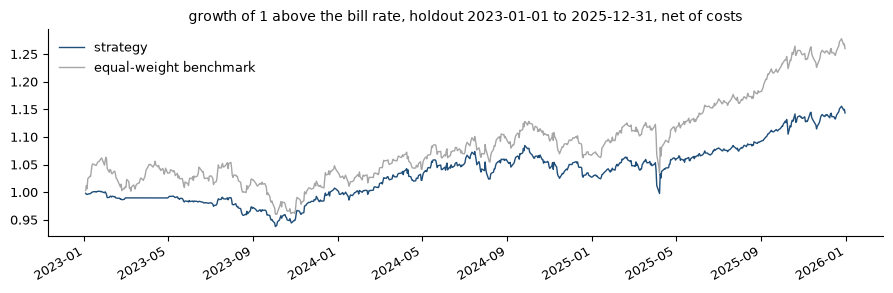

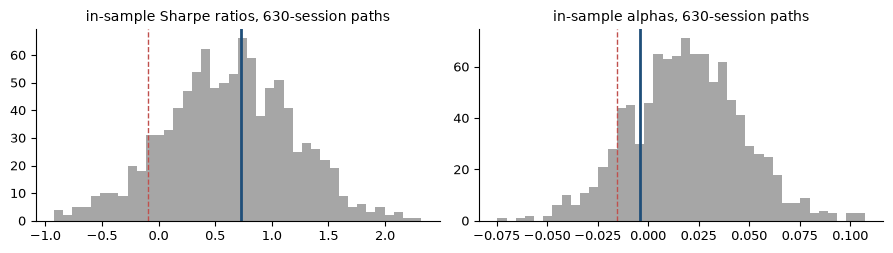

In [12]:
gate(7)
f = gates[7]["figures"]
if "holdout excess" in ev and len(ev["holdout excess"]):
    fig, ax = plt.subplots()
    (1 + ev["holdout excess"]).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + ev["holdout benchmark excess"]).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title(f"growth of 1 above the bill rate, holdout {' to '.join(constants['holdout'])}, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
if "bootstrap" in ev and f:
    pct = constants["percentile"]
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    for axis, key, mark, label in ((a, "Sharpe", "holdout Sharpe", "Sharpe ratio"), (c, "alpha", "holdout alpha", "alpha")):
        axis.hist(ev["bootstrap"][key], bins=40, color=GREY)
        axis.axvline(np.percentile(ev["bootstrap"][key], pct), color=MARK, linestyle="--", linewidth=1)
        axis.axvline(f[mark], color=INK, linewidth=2)
        axis.set_title(f"in-sample {label}s, {constants['window']}-session paths")
    plt.tight_layout()
    display(Markdown(f"Red: the {pct}th percentile of the in-sample paths, the floor; blue: the holdout."))

## Verdict

In [13]:
table = pd.DataFrame([{"gate": f"{g['number']} · {g['name']}",
                       "result": {True: "passes", False: "fails", None: "not computed"}[g["passed"]],
                       "reason": g["reason"].removeprefix("not computed: ")} for g in run["gates"]]).set_index("gate")
display(table)
display(Markdown(f"Thresholds, version {run['thresholds']}. What the verdict means for the theory, and what was "
                 f"learned, is written in [verdict.md](verdict.md)."))

,result,reason
gate,,
1 · Hygiene,passes,"no look-ahead on 200 dates, 203 decisions over 16.9 years"
2 · Economic edge,passes,"Sharpe 0.58 against the benchmark's 0.41, alpha 2.03%, 0.56 at twice the costs"
3 · Significance,fails,"beats 83.9% of its shifted placebos, fewer than 90%"
4 · Multiple testing,fails,DSR 0.840 below 0.9 over 5 effective trials
5 · Stability,fails,the blend of the variants fails gates 3 and 4
6 · Robustness,passes,"neighbours, clusters, assets, bitcoin, delay and survivors all hold"
7 · Sealed holdout,passes,"holdout Sharpe 0.73 and alpha -0.41%, both above the in-sample 10th percentile"


Thresholds, version 1. What the verdict means for the theory, and what was learned, is written in [verdict.md](verdict.md).